In [1]:
#pip install torch transformers

In [2]:
pip install -q transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import GPT2LMHeadModel, GPT2Tokenizer, set_seed

c:\Users\anmrt\Desktop\Useful shit\nlp_labs_8sem\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
np.set_printoptions(precision=3, suppress=True)

In [5]:
#7.1
def softmax_rows(data_in: np.ndarray) -> np.ndarray:
    # Softmax по строкам матрицы
    max_per_row = np.max(data_in, axis=1, keepdims=True)
    exp_values = np.exp(data_in - max_per_row)
    denom = np.sum(exp_values, axis=1, keepdims=True)
    return exp_values / denom

In [6]:
# Одна голова масштабированного self-attention
def single_head_scaled_attention(X, omega_q, omega_k, omega_v, beta_q, beta_k, beta_v):
    D_h, D_full = omega_q.shape
    _, N = X.shape
    ones_row = np.ones((1, N))
    
    Q = omega_q @ X + beta_q @ ones_row  # (D_h, N)
    K = omega_k @ X + beta_k @ ones_row  # (D_h, N)
    V = omega_v @ X + beta_v @ ones_row  # (D_h, N)
    
    E = (Q.T @ K) / np.sqrt(D_h)  # (N, N)
    A = softmax_rows(E)  # (N, N)
    X_head = V @ A.T  # (D_h, N)
    
    return X_head, A

In [7]:
# Многоголовое самовнимание с произвольным числом голов H
def multihead_scaled_self_attention(X, heads_params, omega_c):

    # heads_params: список кортежей (omega_q, omega_k, omega_v, beta_q, beta_k, beta_v)
    H = len(heads_params)
    D_h = heads_params[0][0].shape[0]  # Размерность головы
    
    head_outputs = []
    attention_matrices = []
    
    for h, (omega_q, omega_k, omega_v, beta_q, beta_k, beta_v) in enumerate(heads_params):
        X_head, A = single_head_scaled_attention(X, omega_q, omega_k, omega_v, 
                                               beta_q, beta_k, beta_v)
        head_outputs.append(X_head)
        attention_matrices.append(A)
    
    # Конкатенация по размерности признаков: (H * D_h, N) = (D, N)
    X_concat = np.vstack(head_outputs)
    X_prime = omega_c @ X_concat  # (D, N)
    
    return X_prime, attention_matrices

In [8]:
# Влияние числа голов (эксперимент)
np.random.seed(3)
D = 8
N = 6

X = np.random.normal(size=(D, N))
print("Форма X:", X.shape)

# Генерация параметров для разного числа голов
np.random.seed(0)

# Генерирует параметры для H голов
def generate_heads_params(H, D, D_h):
    heads = []
    for _ in range(H):
        omega_q = np.random.normal(size=(D_h, D))
        omega_k = np.random.normal(size=(D_h, D))
        omega_v = np.random.normal(size=(D_h, D))
        beta_q = np.random.normal(size=(D_h, 1))
        beta_k = np.random.normal(size=(D_h, 1))
        beta_v = np.random.normal(size=(D_h, 1))
        heads.append((omega_q, omega_k, omega_v, beta_q, beta_k, beta_v))
    return heads

omega_c = np.random.normal(size=(D, D))

Форма X: (8, 6)


In [9]:
# H=1
D_h1 = D // 1
heads1 = generate_heads_params(1, D, D_h1)
X1, A1_list = multihead_scaled_self_attention(X, heads1, omega_c)
print(f"H=1: X' shape {X1.shape}, A shape {A1_list[0].shape}")

# H=2  
D_h2 = D // 2
heads2 = generate_heads_params(2, D, D_h2)
X2, A2_list = multihead_scaled_self_attention(X, heads2, omega_c)
print(f"H=2: X' shape {X2.shape}")

# H=4
D_h4 = D // 4
heads4 = generate_heads_params(4, D, D_h4)
X4, A4_list = multihead_scaled_self_attention(X, heads4, omega_c)
print(f"H=4: X' shape {X4.shape}")

H=1: X' shape (8, 6), A shape (6, 6)
H=2: X' shape (8, 6)
H=4: X' shape (8, 6)


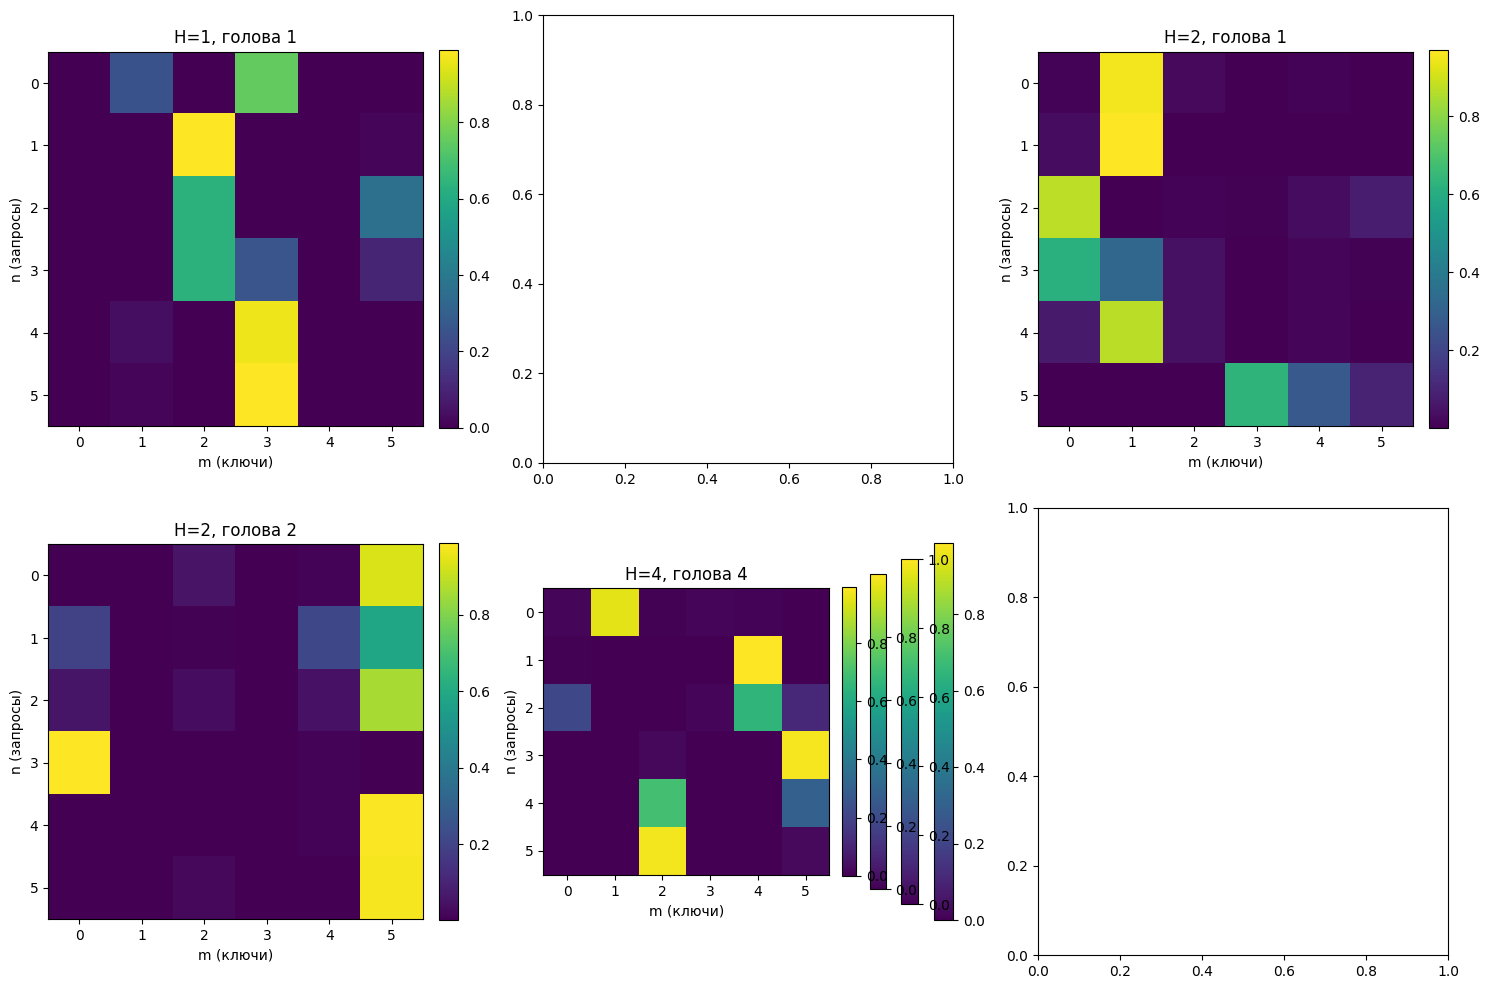


Разница между выходами:
||X1-X2||: 75.84610215383319
||X2-X4||: 120.26721915608319


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (H_name, A_list) in enumerate([("H=1", [A1_list[0]]), ("H=2", A2_list), ("H=4", A4_list)]):
    for head_idx, A in enumerate(A_list):
        ax = axes[i*2 + head_idx] if i < 2 else axes[4]
        im = ax.imshow(A, cmap='viridis')
        ax.set_title(f"{H_name}, голова {head_idx+1}")
        ax.set_xlabel("m (ключи)")
        ax.set_ylabel("n (запросы)")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\nРазница между выходами:")
print("||X1-X2||:", np.linalg.norm(X1 - X2))
print("||X2-X4||:", np.linalg.norm(X2 - X4))

In [11]:
# 7.2
model_name = "distilgpt2"
model = GPT2LMHeadModel.from_pretrained(model_name)
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model.eval()
set_seed(0)
print("Размер словаря:", tokenizer.vocab_size)

c:\Users\anmrt\Desktop\Useful shit\nlp_labs_8sem\venv\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\anmrt\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 859.18it/s, Materializing param=transformer.wte.wei

Размер словаря: 50257


In [ ]:
# Получить распределение по следующему токену
def get_next_token_distribution(input_tokens, model):
    with torch.no_grad():
        outputs = model(**input_tokens)
        logits = outputs.logits[0, -1, :]  # (vocab_size,)
        probs = F.softmax(logits, dim=-1).cpu().numpy()
        return probs

In [ ]:
# Вычислить среднее лог-правдоподобие токенов
def compute_log_likelihood(text, model, tokenizer):
    tokens = tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**tokens)
        logits = outputs.logits  # (1, seq_len, vocab_size)
        
        log_probs = F.log_softmax(logits[0, :-1, :], dim=-1)  # p(x_t+1 | x_1:t)
        targets = tokens['input_ids'][0, 1:]  # x_2:T
        
        log_likelihood = torch.gather(log_probs, 1, 
                                    targets.unsqueeze(1)).squeeze().sum()
        
        return float(log_likelihood) / (tokens['input_ids'].shape[1] - 1)


: 